In [2]:
!pip install mediapipe
!pip install tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 21.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.4
    Uninstalling protobuf-5.29.4:
      Successfully uninstalled protobuf-5.29.4
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
ydf 0.11.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 4.25.7 which is incompatible.
grpcio-

In [2]:
!pip install numpy==2.0.0 mediapipe --upgrade --force-reinstall


  Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.3 kB)
  Using cached mediapipe-0.10.21-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (9.7 kB)
  Using cached protobuf-4.25.7-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
  Using cached sounddevice-0.5.1-py3-none-any.whl.metadata (1.4 kB)
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.5/104.5 kB 9.3 MB/s eta 0:00:00
Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.1 MB)
Using cached mediapipe-0.10.21-cp311-cp311-manylinux_2_28_x86_64.whl (35.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import os
import cv2
import glob
import subprocess
import numpy as np
import librosa
import mediapipe as mp
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile

zip_path = '/content/drive/My Drive/FakeAVCeleb_v1.2.zip'
extract_path = '/content/FakeAVCeleb'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dosyalar şu klasöre çıkarıldı: {extract_path}")

Dosyalar şu klasöre çıkarıldı: /content/FakeAVCeleb


In [5]:
DATASET_DIR = "/content/FakeAVCeleb/FakeAVCeleb_v1.2"
SR = 16000
DURATION = 5.0
N_MFCC = 13
NUM_FRAMES = 10

In [6]:
def get_video_paths_labels(dataset_dir):
    all_paths_labels = []
    # Gerçek ses: hem RealVideo-RealAudio hem de FakeVideo-RealAudio (ses gerçek)
    real_audio_dirs = ["RealVideo-RealAudio", "FakeVideo-RealAudio"]
    # Sahte ses: RealVideo-FakeAudio, FakeVideo-FakeAudio
    fake_audio_dirs = ["RealVideo-FakeAudio", "FakeVideo-FakeAudio"]

    for r_dir in real_audio_dirs:
        path = os.path.join(dataset_dir, r_dir)
        videos = glob.glob(os.path.join(path, "**", "*.mp4"), recursive=True)
        for rv in videos:
            all_paths_labels.append((rv, 0))
    for f_dir in fake_audio_dirs:
        path = os.path.join(dataset_dir, f_dir)
        videos = glob.glob(os.path.join(path, "**", "*.mp4"), recursive=True)
        for fv in videos:
            all_paths_labels.append((fv, 1))
    return all_paths_labels

In [7]:
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True,
                                  max_num_faces=1,
                                  refine_landmarks=True,
                                  min_detection_confidence=0.5)

In [8]:
LIPS = [
    61, 185, 40, 39, 37,   0, 267, 269, 270, 409, 291,
    146, 91, 181, 84, 17, 314, 405, 321, 375,  308,
    78, 95, 88, 178, 87, 14, 317, 402, 318, 324,
    308, 191, 80, 81, 82, 13, 312, 311, 310, 415
]


In [9]:
def extract_lip_region(frame):
    # frame: BGR formatında, OpenCV okur
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb_frame)
    if results.multi_face_landmarks:
        landmarks = results.multi_face_landmarks[0]
        h, w, _ = frame.shape
        xs = [landmark.x * w for idx, landmark in enumerate(landmarks.landmark) if idx in LIPS]
        ys = [landmark.y * h for idx, landmark in enumerate(landmarks.landmark) if idx in LIPS]
        if xs and ys:
            x_min, x_max = int(min(xs)), int(max(xs))
            y_min, y_max = int(min(ys)), int(max(ys))
            # Kırpma yap, biraz margin ekleyebiliriz
            margin = 5
            x_min = max(x_min - margin, 0)
            y_min = max(y_min - margin, 0)
            x_max = min(x_max + margin, w)
            y_max = min(y_max + margin, h)
            lip_region = frame[y_min:y_max, x_min:x_max]
            lip_region = cv2.cvtColor(lip_region, cv2.COLOR_BGR2GRAY)
            lip_region = cv2.resize(lip_region, (64, 64))
            lip_region = np.expand_dims(lip_region, axis=-1)  # (64,64,1)
            return lip_region
    return None


In [10]:
def extract_audio_mfcc(video_path, sr=16000, duration=3.0, n_mfcc=13):
    temp_audio = "temp_audio.wav"
    command = [
        "ffmpeg",
        "-y",
        "-i", video_path,
        "-ac", "1",
        "-ar", str(sr),
        temp_audio
    ]
    subprocess.run(command, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    y, _ = librosa.load(temp_audio, sr=sr, duration=duration)
    target_length = int(sr * duration)
    if len(y) < target_length:
        y = np.concatenate([y, np.zeros(target_length - len(y))])
    else:
        y = y[:target_length]
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc = np.expand_dims(mfcc, axis=-1)  # (n_mfcc, time_frames, 1)
    return mfcc

In [11]:
def prepare_av_sample(video_path, sr=16000, duration=3.0, n_mfcc=13, num_frames=10):
    cap = cv2.VideoCapture(video_path)

    # Videonun 3 saniyelik kısmı için fps * duration kadar kare hedefleniyor
    fps = cap.get(cv2.CAP_PROP_FPS)
    num_target_frames = int(fps * duration) if fps > 0 else 0
    frame_indices = np.linspace(0, max(0, num_target_frames - 1), num_frames, dtype=int)

    current_frame = 0
    selected_frames = []

    while cap.isOpened() and len(selected_frames) < num_frames:
        ret, frame = cap.read()
        if not ret:
            break
        if current_frame in frame_indices:
            lip = extract_lip_region(frame)  # Dudak bölgesi çıkarma fonksiyonunuz
            if lip is not None:
                selected_frames.append(lip)
        current_frame += 1
    cap.release()

    # Eğer hiçbir dudak karesi toplanamadıysa (liste boşsa) None döndür
    if len(selected_frames) == 0:
        return None, None

    # Toplanan kare sayısı hedefin altındaysa, son kareyi tekrar ederek pad et
    if len(selected_frames) < num_frames:
        for _ in range(num_frames - len(selected_frames)):
            selected_frames.append(selected_frames[-1])

    visual_sequence = np.array(selected_frames)  # (num_frames, 64, 64, 1)

    # Ses için MFCC hesapla
    mfcc = extract_audio_mfcc(video_path, sr=sr, duration=duration, n_mfcc=n_mfcc)
    # Eğer mfcc hiç hesaplanamadıysa veya sıfır boyutlu ise None döndür
    if mfcc is None or mfcc.shape[1] == 0:
        return None, None

    # mfcc: (n_mfcc, T, 1) – T, MFCC zaman çerçeveleri sayısı
    T = mfcc.shape[1]
    # Zaman eksenini num_frames segmente bölelim
    mfcc_segments = np.array_split(mfcc, num_frames, axis=1)
    audio_sequence = np.array([segment.mean(axis=1) for segment in mfcc_segments])  # (num_frames, n_mfcc, 1)
    audio_sequence = np.squeeze(audio_sequence, axis=-1)  # (num_frames, n_mfcc)
    audio_sequence = np.expand_dims(audio_sequence, axis=-1)  # (num_frames, n_mfcc, 1)

    return visual_sequence, audio_sequence


In [12]:
def prepare_av_dataset(paths_labels, sr=16000, duration=3.0, n_mfcc=13, num_frames=10):
    X_visual = []
    X_audio = []
    y = []
    for video_path, label in paths_labels:
        visual_seq, audio_seq = prepare_av_sample(video_path, sr=sr, duration=duration, n_mfcc=n_mfcc, num_frames=num_frames)
        if visual_seq is None or audio_seq is None:
            continue
        X_visual.append(visual_seq)
        X_audio.append(audio_seq)
        y.append(label)
    return np.array(X_visual), np.array(X_audio), np.array(y)

In [13]:
def build_visual_branch(input_shape=(10, 64, 64, 1)):
    visual_input = layers.Input(shape=input_shape)
    # Zaman boyutundaki her kare için CNN uygulayalım (TimeDistributed)
    x = layers.TimeDistributed(layers.Conv2D(32, (3,3), activation='relu', padding='same'))(visual_input)
    x = layers.TimeDistributed(layers.MaxPooling2D((2,2)))(x)
    x = layers.TimeDistributed(layers.Conv2D(64, (3,3), activation='relu', padding='same'))(x)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)
    # Şimdi LSTM ile zaman ilişkisini modelleyelim
    x = layers.LSTM(128)(x)
    visual_features = layers.Dense(128, activation='relu')(x)
    return models.Model(visual_input, visual_features, name="visual_branch")

# Ses branch: Zaman serisindeki MFCC segmentlerini işleyen LSTM + CNN
def build_audio_branch(input_shape=(10, 13, 1)):
    audio_input = layers.Input(shape=input_shape)
    # Zaman boyutundaki her MFCC segmenti için küçük CNN
    x = layers.TimeDistributed(layers.Conv1D(16, 3, activation='relu', padding='same'))(audio_input)
    x = layers.TimeDistributed(layers.MaxPooling1D(2))(x)
    x = layers.TimeDistributed(layers.Conv1D(32, 3, activation='relu', padding='same'))(x)
    x = layers.TimeDistributed(layers.GlobalAveragePooling1D())(x)
    x = layers.LSTM(128)(x)
    audio_features = layers.Dense(128, activation='relu')(x)
    return models.Model(audio_input, audio_features, name="audio_branch")

# Audio-Visual Model: İki branch'in çıktısını birleştirip senkronizasyon ve deepfake tespiti yapar
def build_av_model(visual_input_shape=(10, 64, 64, 1), audio_input_shape=(10, 13, 1)):
    visual_branch = build_visual_branch(visual_input_shape)
    audio_branch = build_audio_branch(audio_input_shape)
    combined = layers.concatenate([visual_branch.output, audio_branch.output])
    x = layers.Dense(64, activation='relu')(combined)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs=[visual_branch.input, audio_branch.input], outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [14]:
paths_labels = get_video_paths_labels(DATASET_DIR)
print("Toplam örnek sayısı:", len(paths_labels))

Toplam örnek sayısı: 21544


In [15]:
train_paths, test_paths = train_test_split(paths_labels, test_size=0.2, random_state=42, stratify=[lbl for _, lbl in paths_labels])
print("Eğitim örnek sayısı:", len(train_paths))
print("Test örnek sayısı:", len(test_paths))

print("Veri hazırlanıyor (audio-visual)...")
X_visual_train, X_audio_train, y_train = prepare_av_dataset(train_paths, sr=SR, duration=DURATION, n_mfcc=N_MFCC, num_frames=NUM_FRAMES)
X_visual_test, X_audio_test, y_test = prepare_av_dataset(test_paths, sr=SR, duration=DURATION, n_mfcc=N_MFCC, num_frames=NUM_FRAMES)
print("Eğitim görsel verisi şekli:", X_visual_train.shape)
print("Eğitim ses verisi şekli:", X_audio_train.shape)
print("Test görsel verisi şekli:", X_visual_test.shape)
print("Test ses verisi şekli:", X_audio_test.shape)

Eğitim örnek sayısı: 17235
Test örnek sayısı: 4309
Veri hazırlanıyor (audio-visual)...
Eğitim görsel verisi şekli: (17234, 10, 64, 64, 1)
Eğitim ses verisi şekli: (17234, 10, 13, 1)
Test görsel verisi şekli: (4307, 10, 64, 64, 1)
Test ses verisi şekli: (4307, 10, 13, 1)


In [17]:
# Modeli oluştur
av_model = build_av_model(visual_input_shape=(NUM_FRAMES, 64, 64, 1), audio_input_shape=(NUM_FRAMES, N_MFCC, 1))
av_model.summary()

# Modeli eğit
history = av_model.fit([X_visual_train, X_audio_train], y_train, epochs=10, batch_size=16, validation_split=0.2)

# Modeli test et
test_loss, test_acc = av_model.evaluate([X_visual_test, X_audio_test], y_test)
print("Test Loss:", test_loss, "Test Accuracy:", test_acc)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 64,    │          0 │ -                 │
│ (InputLayer)        │ 64, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 10, 13, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 10, 64,    │        320 │ input_layer[0][0] │
│ (TimeDistributed)   │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_4  │ (None, 10, 13,    │         64 │ input_layer_1[0]… │
│ (TimeDistributed)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 10, 32,    │          0 │ time_distributed… │
│ (TimeDistributed)   │ 32, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_5  │ (None, 10, 6, 16) │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 10, 32,    │     18,496 │ time_distributed… │
│ (TimeDistributed)   │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_6  │ (None, 10, 6, 32) │      1,568 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_3  │ (None, 10, 64)    │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_7  │ (None, 10, 32)    │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │     98,816 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 128)       │     82,432 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     16,448 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 251,233 (981.38 KB)

 Trainable params: 251,233 (981.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
862/862 ━━━━━━━━━━━━━━━━━━━━ 59s 56ms/step - accuracy: 0.9754 - loss: 0.1263 - val_accuracy: 0.9753 - val_loss: 0.1102
Epoch 2/10
862/862 ━━━━━━━━━━━━━━━━━━━━ 75s 50ms/step - accuracy: 0.9766 - loss: 0.1203 - val_accuracy: 0.9753 - val_loss: 0.1207
Epoch 3/10
862/862 ━━━━━━━━━━━━━━━━━━━━ 82s 50ms/step - accuracy: 0.9760 - loss: 0.1186 - val_accuracy: 0.9753 - val_loss: 0.1135
Epoch 4/10
862/862 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.9773 - loss: 0.1108 - val_accuracy: 0.9753 - val_loss: 0.1054
Epoch 5/10
862/862 ━━━━━━━━━━━━━━━━━━━━ 82s 50ms/step - accuracy: 0.9768 - loss: 0.1141 - val_accuracy: 0.9753 - val_loss: 0.1054
Epoch 6/10
862/862 ━━━━━━━━━━━━━━━━━━━━ 82s 50ms/step - accuracy: 0.9771 - loss: 0.1069 - val_accuracy: 0.9753 - val_loss: 0.1098
Epoch 7/10
862/862 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - accuracy: 0.9778 - loss: 0.1073 - val_accuracy: 0.9753 - val_loss: 0.1036
Epoch 8/10
862/862 ━━━━━━━━━━━━━━━━━━━━ 84s 53ms/step - accuracy: 0.9757 - loss: 0.1089 - 

135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step
Confusion Matrix:
[[1997   43]
 [   2 2265]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2040
           1       0.98      1.00      0.99      2267

    accuracy                           0.99      4307
   macro avg       0.99      0.99      0.99      4307
weighted avg       0.99      0.99      0.99      4307

ROC AUC Score: 0.9998216092789123
F1 Score: 0.9901639344262295
Precision: 0.9813691507798961
Recall: 0.9991177767975298


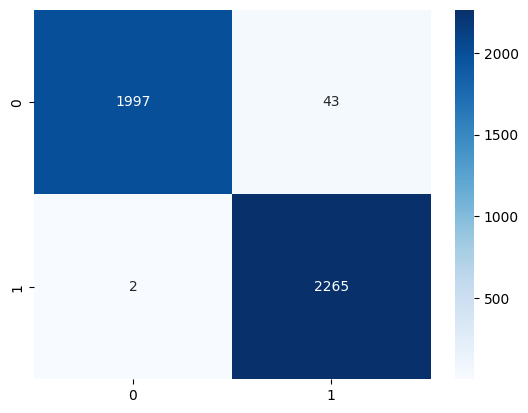

In [17]:
from tensorflow.keras.models import load_model
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, f1_score, precision_score, recall_score

# 🔹 1. Kaydedilmiş modeli yükle
saved_model_path = "/content/drive/My Drive/cnn_lip_model.h5"
model = load_model(saved_model_path)

# 🔹 2. Test verisini kontrol et (multimodal giriş)
# Eğer model hem görüntü hem ses alıyorsa:
X_input_test = [X_visual_test, X_audio_test]  # ← çoklu girişli model için

# 🔹 3. Tahmin yap
pred_probs = model.predict(X_input_test)

# 🔹 4. Eşik belirleyerek sınıf etiketine çevir
pred_labels = (pred_probs > 0.5).astype(int)

# 🔹 5. Metriklerin hesaplanması
print("Confusion Matrix:")
cm = confusion_matrix(y_test, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, pred_labels))

roc_auc = roc_auc_score(y_test, pred_probs)
f1 = f1_score(y_test, pred_labels)
precision = precision_score(y_test, pred_labels)
recall = recall_score(y_test, pred_labels)

print("ROC AUC Score:", roc_auc)
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)


In [ ]:
test_loss, test_acc = av_model.evaluate([X_visual_test, X_audio_test], y_test)
print("Test Loss:", test_loss, "Test Accuracy:", test_acc)

135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9838 - loss: 0.0486
Test Loss: 0.03916839137673378 Test Accuracy: 0.9870009422302246


In [ ]:
av_model.save("cnn_lip_model.h5")
import shutil
shutil.move("cnn_lip_model.h5", "/content/drive/My Drive/cnn_lip_model.h5")

'/content/drive/My Drive/cnn_lip_model.h5'